# Submission Notebook for 2026 Machine Learning Kaggle Competition
**Authors:** Zach Loo, Nathalie Bonnet, Leela Dixit, Jay Kim

**Date:** 06/11/2026

# Background
This notebook contains the code written to predict dissolved organic carbon (DIC) for California coastal waters. The data used to train regression models come from the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program, which monitors oceanographic conditions over time. The data contains DIC data from samples, and predictor features for sea water temperature, alkalinity, practical saliity, and sample depth. The goals of this notebook were to:
1. Explore sample data that can inform modeling decisions
2. Fit models to minimize tets MSE (obtain the best fitting model than can be generalized for other data)
3. Compare model results, comment on performance, and select an optimal model. 

**Citation and Acknowledgements:** Data are provided by the California Cooperative Oceanic Fisheries Investigations (CalCOFI) program (https://calcofi.org). CalCOFI is a partnership among the NOAA Fisheries Service, the Scripps Institution of Oceanography, and the California Department of Fish and Wildlife.

# Setup

This section installs any missing packages, loads the libraries used in the notebook, and reads in the data. It includes standard tools for data handling and plotting, scikit-learn models and utilities, PCA, stacking, support vector regression, and the gradient-boosting models XGBoost, LightGBM, and CatBoost. Optuna is also loaded for hyperparameter tuning. The commented pip lines can be run once if LightGBM, CatBoost, or Optuna are not already installed. After loading the packages, we read in the training data, test data, and the sample submission file used to format predictions.

In [8]:
# Install these package if needed
# pip install lightgbm --quiet
# pip install catboost --quiet
# pip install optuna --quiet

# Load packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # since nathalie & leela is windows user tehe
import optuna
from matplotlib.pyplot import figure, show
from matplotlib.ticker import MaxNLocator
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.decomposition import PCA
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
# Load training and test data
train = pd.read_csv(os.path.join("data", "train.csv"))
test = pd.read_csv(os.path.join("data", "test.csv"))

# Load submission example
submission = pd.read_csv(os.path.join("data", "sample_submission.csv"))

In [3]:
# Create names list of features
features = ["CTDTEMP_ITS90", "TA", "Salinity_PSS78", "Depth"]

In [4]:
# Explore data
train.info()

# Create summary statistics table 
stats = train[features].agg(['mean', 'median', 'min', 'max', 'std'])
print(stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3389 entries, 0 to 3388
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              3389 non-null   int64  
 1   CTDTEMP_ITS90   3389 non-null   float64
 2   Salinity_PSS78  3389 non-null   float64
 3   Depth           3389 non-null   float64
 4   TA              3389 non-null   float64
 5   DIC             3389 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 159.0 KB
        CTDTEMP_ITS90           TA  Salinity_PSS78        Depth
mean        11.819258  2251.047300       33.701898   144.232546
median      11.230000  2241.000000       33.609500    50.000000
min          1.520000  2163.800000       32.700000     0.000000
max         22.750000  2462.300000       34.680000  3542.000000
std          3.905980    32.675546        0.375517   262.640488


From a couple preliminary explorations, all data is non-null, so no need for any scrubbing! However, the scale of the features does not match at all, which can result in models unfairly penalizing larger features. So, we should scale the feature data.

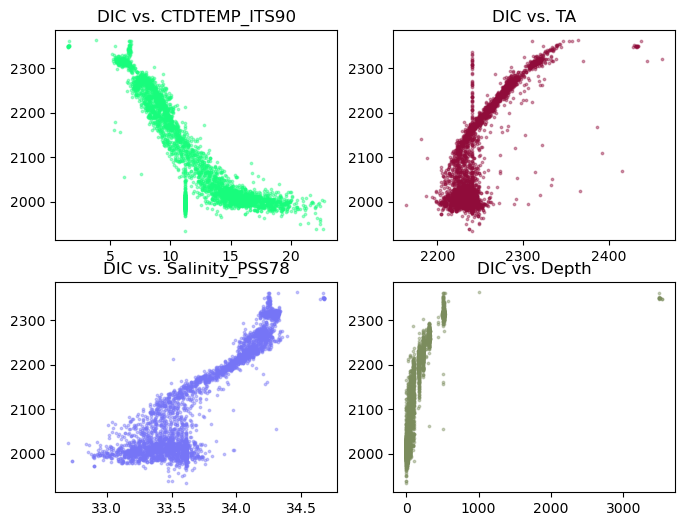

In [5]:
# Plot relationships of predictors & response
fig, axes = plt.subplots(2, 2, figsize = (8, 6))
axes = axes.flatten()
for ax, feature in zip(axes, features):
    ax.scatter(train[feature], train["DIC"], s = 3, alpha = 0.4, color = np.random.rand(3))
    ax.set_title(f"DIC vs. {feature}")

Based on this preliminary visualization, it seems that most predictors have some relationship with DIC, though possibly not ones that can be summarized by linear models. Let's try though.

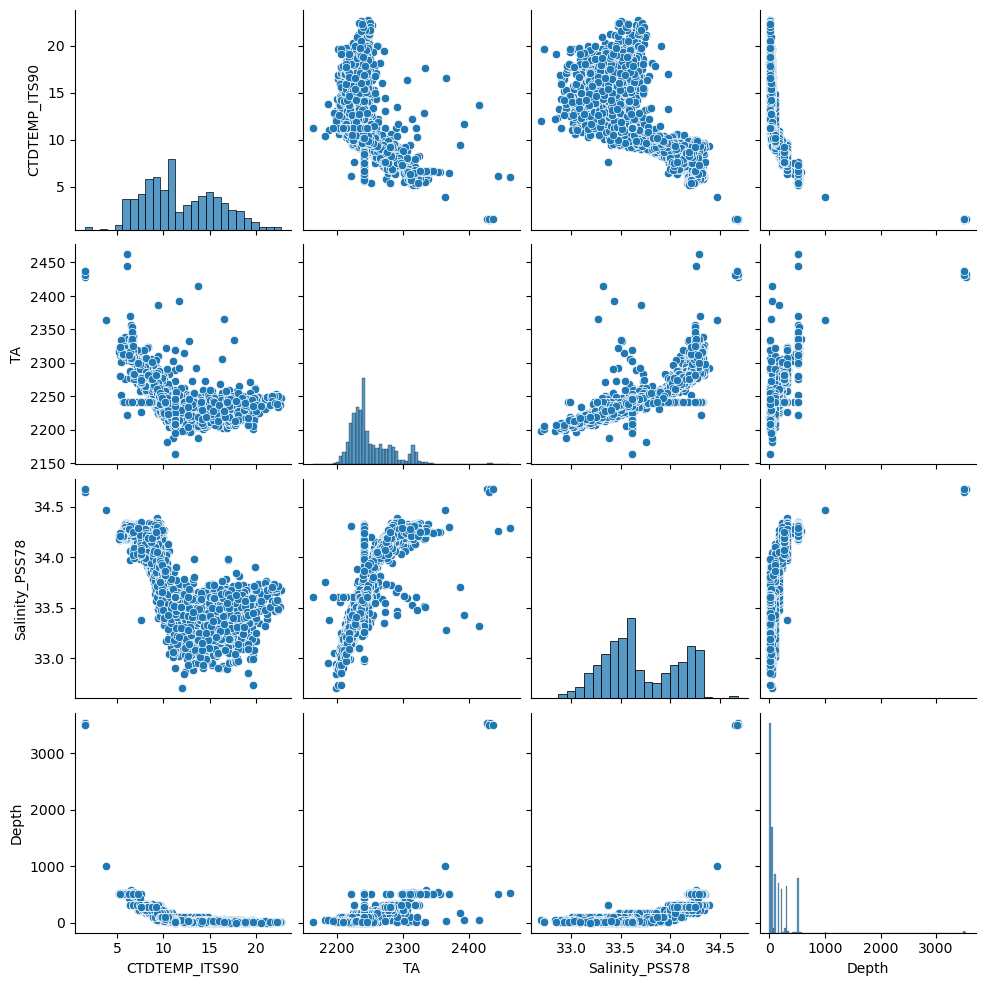

In [6]:
sns.pairplot(train[features]);

In [9]:
# Prepare train data for model fitting
X_train = train[features]
y_train = train["DIC"]

X_test = test[features]

# Apply scalar to X values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

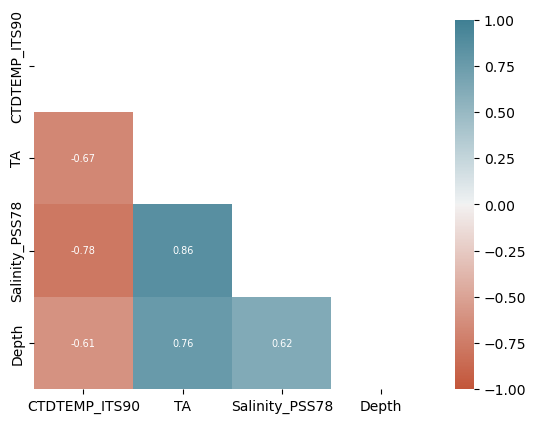

In [ ]:
# Correlation heatmap of the selected features, showing only the lower triangle
corrmat = train[features].corr()
mask= np.zeros_like(corrmat)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corrmat,
            vmax = 1, vmin = -1,
            annot = True, annot_kws = {'fontsize': 7},
            mask = mask,
            cmap = sns.diverging_palette(20, 220, as_cmap = True));

When looking at our predictors plotted against each other, we can see there is likely some correlation between predictors, particularly between salinity and total alkalinity, salinity and temperature, and depth and total alkalinity.

## Mod 1. OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [7]:
# OLS model
ols = LinearRegression().fit(X_train_scaled, y_train)

# Find training MSE
mse_ols = mean_squared_error(y_train, ols.predict(X_train_scaled))

print(f"[ols] Training MSE: {mse_ols}")

# Generate submission on test data
submission["DIC"] = ols.predict(X_test_scaled)

# Overwrite submission with one prediction per row
submission.to_csv("output/submission_ols.csv", index = False)

[ols] Training MSE: 1438.785117036232


## Mod 2-5. Polynomial and RBF SVR, Lasso and Ridge Regression

Four models that extend the linear baseline. Ridge and Lasso add regularization to penalize large coefficients (Lasso can also zero features out), while the polynomial and RBF support vector regressors allow curved, nonlinear relationships. Each is tuned with a cross-validated grid search over its key hyperparameters.

In [16]:
# Create grid search matrix
models = {
    "poly": GridSearchCV(
        SVR(kernel = 'poly'),
        {'C': [0.1, 1, 10, 100], 
         'gamma': ['scale', 0.001, 0.01, 0.1, 1], 
         'degree': [2, 3, 4], 'coef0': [0, 1]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "rbf": GridSearchCV(
        SVR(kernel = 'rbf'),
        {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.01, 0.1, 1, 10]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "lasso": GridSearchCV(
        Lasso(),
        {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "ridge": GridSearchCV(
        Ridge(),
        {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
        cv = 5, scoring = 'neg_mean_squared_error', n_jobs = -1)}

# Loop through each model, fit and extract the best estimator, and generate predictions for those parameters
for name, grid in models.items():
    grid.fit(X_train_scaled, y_train)
    best = grid.best_estimator_
    
    train_mse = mean_squared_error(y_train, best.predict(X_train_scaled))
    print(f"[{name}] Train MSE: {train_mse:.3f} | Best params: {grid.best_params_}")

# Write the final submission
    sub = submission.copy()
    sub["DIC"] = best.predict(X_test_scaled)
    sub.to_csv(f"output/submission_{name}.csv", index = False)

[poly] Train MSE: 951.798 | Best params: {'C': 1, 'coef0': 1, 'degree': 4, 'gamma': 0.1}
[rbf] Train MSE: 329.811 | Best params: {'C': 100, 'gamma': 1}
[lasso] Train MSE: 1440.002 | Best params: {'alpha': 1}
[ridge] Train MSE: 1438.846 | Best params: {'alpha': 10}


# Mod 6. XGB and LGBM models

Two gradient-boosted tree models, each tuned with a cross-validated grid search over its key hyperparameters (number of trees, tree size, learning rate, and regularization). We use shuffled 5-fold CV, which is important here because the data is ordered by depth and station, and select the configuration with the lowest cross-validated MSE. A stacking ensemble that combines the two tuned tree models. Their cross-validated predictions are passed to a Ridge meta-learner, which learns how to blend them into a single estimate. Because XGB and LGBM make slightly different errors, combining them produces a lower CV MSE than either model alone, which is why we use the stack for the final submission.

In [ ]:
# Keep feature names on scaled data to silences LightGBM warnings
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns = features)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns = features)

# Shuffle matters! Data is ordered by depth
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

# Create grid search matrix
models = {
    "xgb": GridSearchCV(
        XGBRegressor(random_state = 42, n_jobs = -1),
        {'n_estimators': [100, 300, 500], 'max_depth': [3, 5, 7], 
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0], 
         'reg_lambda': [1, 10]},
        cv = kf, scoring = 'neg_mean_squared_error', n_jobs = -1),
    "lgbm": GridSearchCV(
        LGBMRegressor(random_state = 42, verbose = -1),
        {'n_estimators': [300, 500], 'num_leaves': [31, 63],
         'learning_rate': [0.05, 0.1], 'subsample': [0.8, 1.0], 
         'min_child_samples': [10, 30]},
        cv = kf, scoring = 'neg_mean_squared_error', n_jobs = -1)}

# Store the best fitted model and save its test predictions
best_models = {}
for name, grid in models.items():
    grid.fit(X_train_scaled, y_train)
    best_models[name] = grid.best_estimator_
    print(f"[{name}] CV MSE: {-grid.best_score_:.3f} | Best params: {grid.best_params_}")

    sub = submission.copy()
    sub["DIC"] = grid.best_estimator_.predict(X_test_scaled)
    sub.to_csv(f"output/submission_{name}.csv", index = False)

# Name estimators for stacking
best_xgb  = best_models["xgb"]
best_lgbm = best_models["lgbm"]

[xgb] CV MSE: 194.089 | Best params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 10, 'subsample': 1.0}
[lgbm] CV MSE: 197.539 | Best params: {'learning_rate': 0.05, 'min_child_samples': 10, 'n_estimators': 300, 'num_leaves': 31, 'subsample': 0.8}


In [11]:
# Stacking
stack = StackingRegressor(
    estimators = [('xgb', best_xgb), ('lgbm', best_lgbm)],
    final_estimator = Ridge(), cv = kf, n_jobs = -1)

# Performance estimate
stack_cv = -cross_val_score(stack, X_train_scaled, y_train, cv = kf,
                            scoring = 'neg_mean_squared_error').mean()
print(f"[stack] CV MSE: {stack_cv:.3f}")

# Fit on all training data and write the final submission
stack.fit(X_train_scaled, y_train)
sub = submission.copy()
sub["DIC"] = stack.predict(X_test_scaled)
sub.to_csv("output/submission_stack.csv", index = False)

[stack] CV MSE: 190.377


# Mod 7. Optuna-Tuned CatBoost, XGB and LGBM Stack

This section re-tunes the same two gradient-boosted models from Mod 6, but replaces the grid search with Optuna, an adaptive hyperparameter optimizer. Instead of testing a fixed list of values, Optuna samples from continuous ranges and uses the results of earlier trials to steer toward promising regions, so it can land on settings a discrete grid would skip over (for example a learning rate of 0.07 rather than just 0.05 or 0.1). Each trial is scored by shuffled 5-fold cross-validated MSE. The best CatBoost, XGB, and LGBM configurations are then combined in the same Ridge-stacked ensemble used in Mod 7. This version produced our lowest cross-validated MSE, so its predictions are our final submission.

In [12]:
# Silence warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

# Each objective lets Optuna pick a set of hyperparameters
# Returns that model's mean 5-fold CV MSE for Optuna to minimize
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log = True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log = True),
        'random_state': 42, 'n_jobs': -1}
    m = XGBRegressor(**params)
    return -cross_val_score(m, X_train_scaled, y_train, cv = kf,
                            scoring = 'neg_mean_squared_error').mean()

def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800),
        'num_leaves': trial.suggest_int('num_leaves', 15, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log = True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1}
    m = LGBMRegressor(**params)
    return -cross_val_score(m, X_train_scaled, y_train, cv = kf,
                            scoring = 'neg_mean_squared_error').mean()

# Seeded sampler so re-runs give the same result
study_xgb = optuna.create_study(direction = 'minimize',
                                sampler = optuna.samplers.TPESampler(seed = 42))
study_xgb.optimize(xgb_objective, n_trials = 30)

study_lgbm = optuna.create_study(direction = 'minimize',
                                 sampler = optuna.samplers.TPESampler(seed = 42))
study_lgbm.optimize(lgbm_objective, n_trials = 30)

print(f"[xgb-optuna] CV MSE: {study_xgb.best_value:.3f} | {study_xgb.best_params}")
print(f"[lgbm-optuna] CV MSE: {study_lgbm.best_value:.3f} | {study_lgbm.best_params}")

# Build tuned estimators to separate `_opt` names so other mod grid models stay intact
best_xgb_opt  = XGBRegressor(**study_xgb.best_params,  random_state = 42, n_jobs = -1)
best_lgbm_opt = LGBMRegressor(**study_lgbm.best_params, random_state = 42, n_jobs = -1, verbose = -1)

# CatBoost is pre-tuned to low learning rate and many symmetric trees works well
best_cat_opt = CatBoostRegressor(iterations = 1500, depth = 7, learning_rate = 0.02,
                                 l2_leaf_reg = 5, random_state = 42, verbose = 0)
cat_cv = -cross_val_score(best_cat_opt, X_train_scaled, y_train, cv = kf,
                          scoring = 'neg_mean_squared_error').mean()
print(f"[catboost] CV MSE: {cat_cv:.3f}")

# Save the individual optuna-tuned submissions
for name, model in [("xgb_optuna", best_xgb_opt), ("lgbm_optuna", best_lgbm_opt), ("catboost", best_cat_opt)]:
    model.fit(X_train_scaled, y_train)
    sub = submission.copy()
    sub["DIC"] = model.predict(X_test_scaled)
    sub.to_csv(f"output/submission_{name}.csv", index = False)

[xgb-optuna] CV MSE: 193.349 | {'n_estimators': 773, 'max_depth': 7, 'learning_rate': 0.010277847082572428, 'subsample': 0.951259592815969, 'reg_lambda': 4.285250297417102}
[lgbm-optuna] CV MSE: 202.642 | {'n_estimators': 671, 'num_leaves': 32, 'learning_rate': 0.05748924681991978, 'subsample': 0.836965827544817, 'min_child_samples': 7}
[catboost] CV MSE: 184.912


In [13]:
# Stack the optuna-tuned models
stack_opt = StackingRegressor(
    estimators = [('xgb', best_xgb_opt), ('lgbm', best_lgbm_opt), ('cat', best_cat_opt)],
    final_estimator = Ridge(), cv = kf, n_jobs = -1)

# Performance estimate
stack_opt_cv = -cross_val_score(stack_opt, X_train_scaled, y_train, cv = kf,
                                scoring = 'neg_mean_squared_error').mean()
print(f"[stack-optuna] CV MSE: {stack_opt_cv:.3f}")

# Fit on all training data and write the final submission
stack_opt.fit(X_train_scaled, y_train)
sub = submission.copy()
sub["DIC"] = stack_opt.predict(X_test_scaled)
sub.to_csv("output/submission_stack_catboost.csv", index = False)

[stack-optuna] CV MSE: 181.379


# Mod 8. Principal Component Regression

This section uses PCA to turn the four predictors into a smaller set of uncorrelated components before fitting a linear regression. We keep enough components to explain about 90% of the variance, apply the same transformation to the training and test data, and then fit the model. PCR helps assess whether reducing correlated features improves performance while also serving as a linear-model comparison with the tree-based methods.

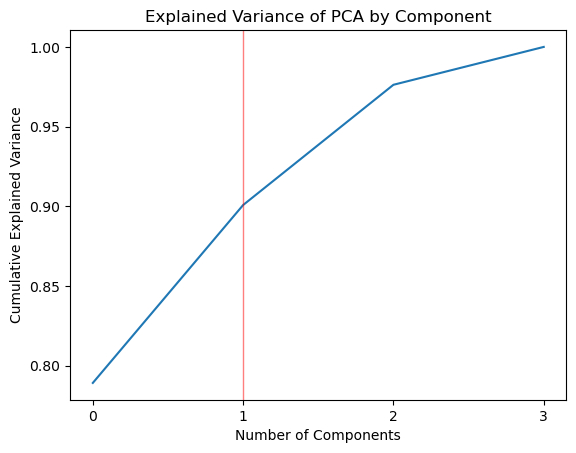

Number of components explaining 90% variance: 1
[pcr] Training MSE: 2349.6762


In [14]:
# Initalize PCA 
pca = PCA()
pca.fit(X_train_scaled).transform(X_train_scaled)

# Scree plot
def var_explained():
    ax = figure().gca()
    ax.plot(np.cumsum(pca.explained_variance_ratio_))
    ax.xaxis.set_major_locator(MaxNLocator(integer = True))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.axvline(x = 1, linewidth = 1, color = 'r', alpha = 0.5)
    plt.title('Explained Variance of PCA by Component')
    show()

var_explained()

# Find how many components to use
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90)
print(f"Number of components explaining 90% variance: {n_components}")

# Re-run pca to transform on one component
pcr = PCA(n_components = n_components)
X_train_pca = pcr.fit_transform(X_train_scaled)
X_test_pca = pcr.transform(X_test_scaled)

# Run linear regression on components
pcr_linear = LinearRegression()
pcr_linear.fit(X_train_pca, y_train)

mse_pcr = mean_squared_error(y_train, pcr_linear.predict(X_train_pca))
print(f"[pcr] Training MSE: {mse_pcr:.4f}")

# Save predictions for kaggle
sub = submission.copy()
sub["DIC"] = pcr_linear.predict(X_test_pca)
sub.to_csv(f"output/submission_pcr.csv", index = False)

# Mod 9. Random Forest

This section utilizes the random forest ensemble learning method that aggregates the output of multiple decision trees into a single MSE. This method uses bootstrapping and randomizing predictors to create a large number of independent trees, that when averaged should produce a large reduction in variance.

In [ ]:
# Initialize RF model
rf_reg = RandomForestRegressor(random_state = 42)

# Define hyperparameter search space
param_grid = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [None, 5, 10, 20],
    'max_features': ['sqrt', 'log2', 0.3],
    'min_samples_leaf': [1, 5]
}

# Run 5-fold CV grid search
rf_grid = GridSearchCV(rf_reg, param_grid, cv = 5, scoring = 'neg_mean_squared_error')
rf_grid.fit(X_train, y_train)
# Print best MSE & parameter
print(f"[rf] MSE: {-rf_grid.best_score_:.2f} | Best parameters: {rf_grid.best_params_}")

# Generate and save test predictions
rf_pred = rf_grid.predict(test[features])
submission_rf = pd.DataFrame({"id": test["id"], "DIC": rf_pred})
submission_rf.to_csv("output/submission_rf.csv", index = False)

[rf] MSE: 360.46 | Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 500}


# Summary

In [7]:
all_mse = pd.DataFrame({'model': ['OLS', 'Polynomial SVR', 'RBF SVR', 
                                  'Lasso', 'Ridge', 'XGB', 
                                  'LGBM', 'XGB/LGBM Stack', 'XGB Optuna', 
                                  'LGBM Optuna', 'Catboost', 'Optuna-Tuned Stack', 
                                  'PCR', 'RF'],
                       'Training MSE': ['1438.785', '951.798', '329.811', 
                                        '1440.002', '1438.846', '194.089', 
                                        '197.539', '190.377', '193.349', 
                                        '202.642', '184.912', '181.379', 
                                        '2349.676', '360.59']})
all_mse

,model,Training MSE
0,OLS,1438.785
1,Polynomial SVR,951.798
2,RBF SVR,329.811
3,Lasso,1440.002
4,Ridge,1438.846
5,XGB,194.089
6,LGBM,197.539
7,XGB/LGBM Stack,190.377
8,XGB Optuna,193.349
9,LGBM Optuna,202.642


We can see from our training MSEs that the Optuna-tuned XGB, LGBM, and catboost stacked model performed the best with the lowest training MSE.

The linear-based models performed the worst, likely because our data do not follow a linear relationship. We wanted to increase flexibility due to the non-linear relationship, which led us to explore unsupervised methods such as gradient boosting and CatBoost. We implemented stacking, an ensemble method that further decreases error by averaging over multiple types of models. This decreased training MSE to our final lowest value of ~181.